In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv(
    "../data/processed/telco_person3_week1_cleaned_encoded.csv"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Dataset loaded successfully!
Shape: (7043, 31)
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0            0   
1              0      34           56.95       1889.50      0            1   
2              0       2           53.85        108.15      1            1   
3              0      45           42.30       1840.75      0            1   
4              0       2           70.70        151.65      1            0   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0            1               0                 0   
1            0               0                 1   
2            0               0                 1   
3            0               0                 0   
4            0               0                 1   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                               1  ...                                0   
1                    

Feature Correlation Analysis

In [3]:
correlation_matrix = df.corr(numeric_only=True)

print("Correlation matrix created successfully!")
print("\nTop features correlated with Churn:")
print(
    correlation_matrix["Churn"]
    .sort_values(ascending=False)
    .head(10)
)

Correlation matrix created successfully!

Top features correlated with Churn:
Churn                             1.000000
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
PaperlessBilling_Yes              0.191825
SeniorCitizen                     0.150889
StreamingTV_Yes                   0.063228
StreamingMovies_Yes               0.061382
MultipleLines_Yes                 0.040102
PhoneService_Yes                  0.011942
Name: Churn, dtype: float64


Feature Correlation Analysis

In [4]:
correlation_matrix = df.corr(numeric_only=True)

print("Correlation matrix created successfully!")

print("\nTop 10 features correlated with Churn:")

top_correlations = (
    correlation_matrix["Churn"]
    .drop("Churn")
    .sort_values(ascending=False)
    .head(10)
)

print(top_correlations)

Correlation matrix created successfully!

Top 10 features correlated with Churn:
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
PaperlessBilling_Yes              0.191825
SeniorCitizen                     0.150889
StreamingTV_Yes                   0.063228
StreamingMovies_Yes               0.061382
MultipleLines_Yes                 0.040102
PhoneService_Yes                  0.011942
gender_Male                      -0.008612
Name: Churn, dtype: float64


Negative correlation

In [5]:
print("Top 10 negative correlations with Churn:")

negative_correlations = (
    correlation_matrix["Churn"]
    .drop("Churn")
    .sort_values(ascending=True)
    .head(10)
)

print(negative_correlations)

Top 10 negative correlations with Churn:
tenure                                 -0.352229
Contract_Two year                      -0.302253
OnlineSecurity_No internet service     -0.227890
OnlineBackup_No internet service       -0.227890
TechSupport_No internet service        -0.227890
StreamingMovies_No internet service    -0.227890
DeviceProtection_No internet service   -0.227890
InternetService_No                     -0.227890
StreamingTV_No internet service        -0.227890
TotalCharges                           -0.198324
Name: Churn, dtype: float64


Full Correlation Heatmap

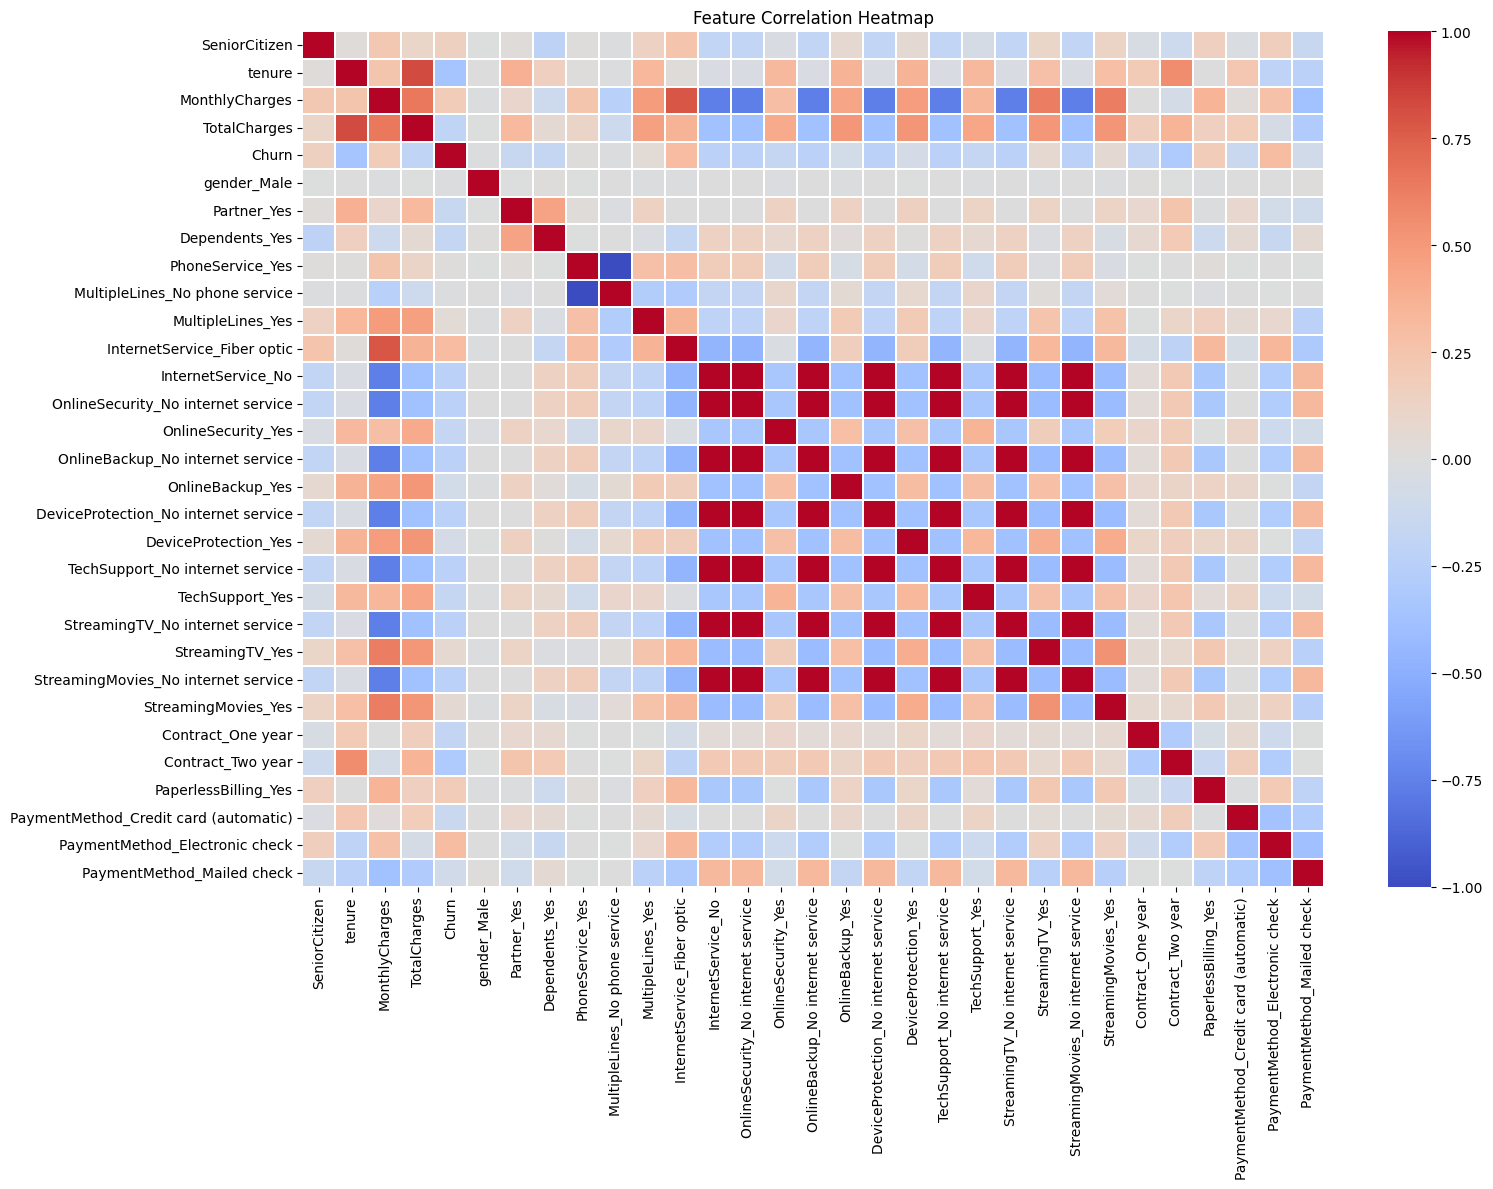

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

Save Heatmap

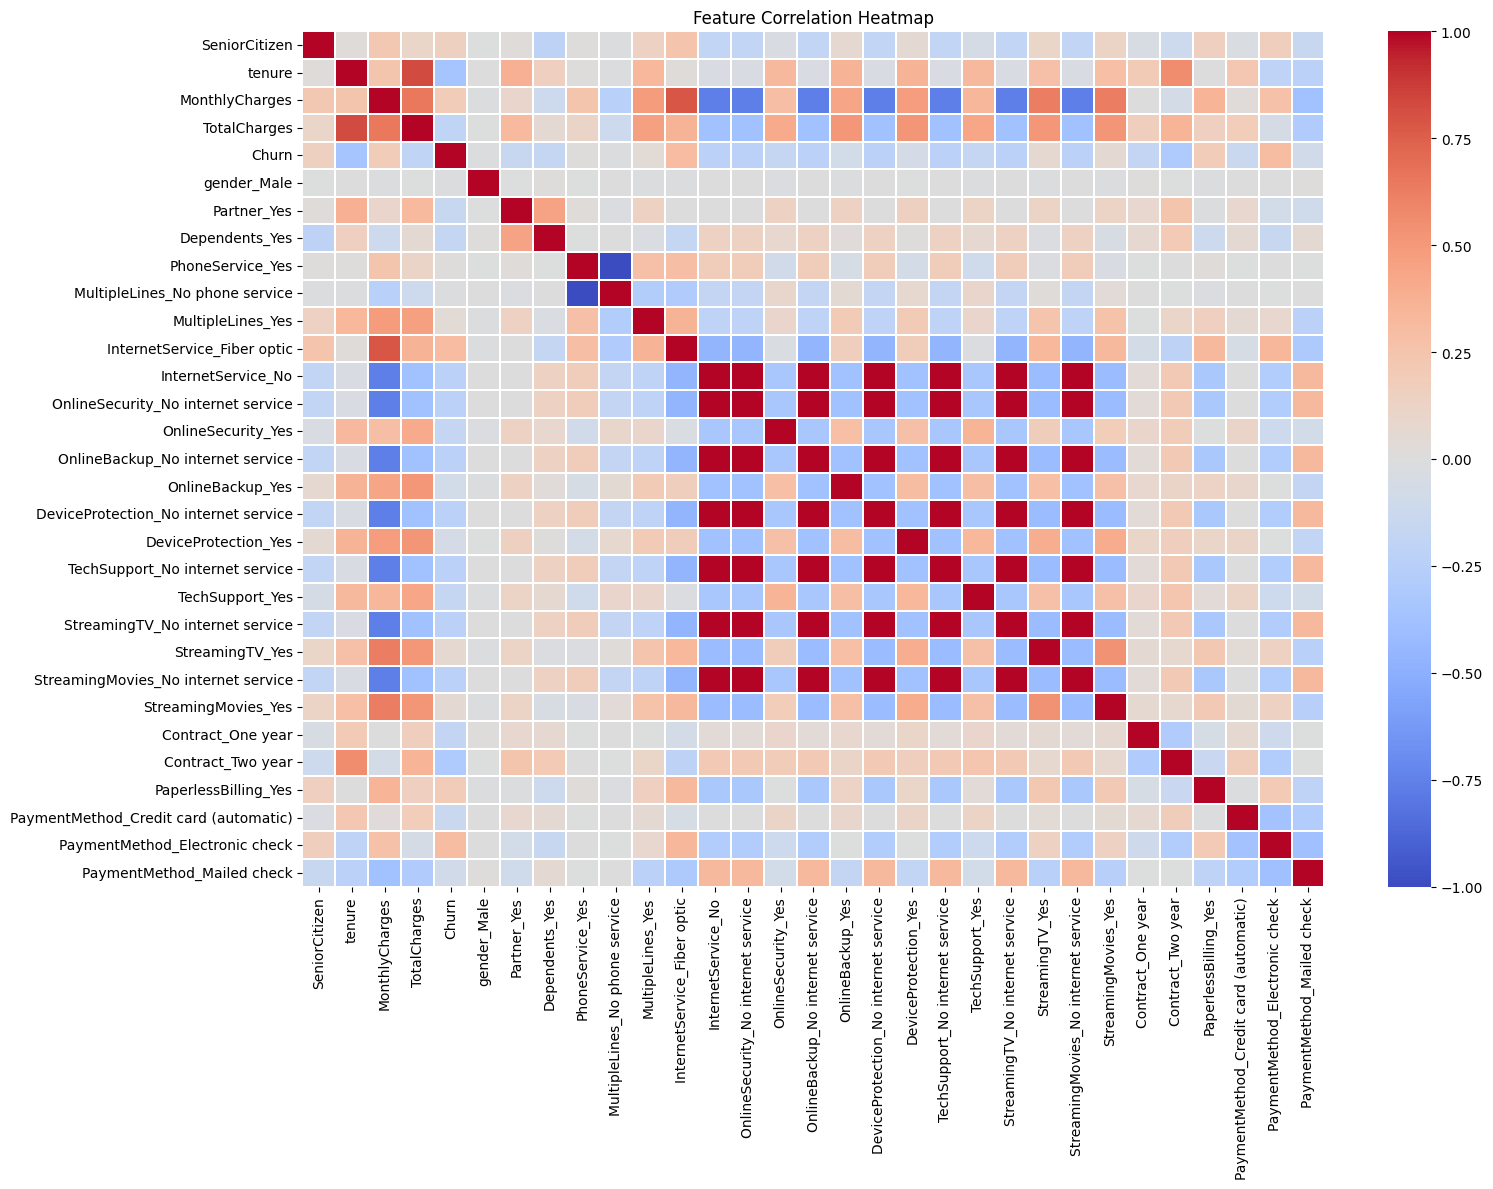

Correlation heatmap saved successfully!


In [7]:
import os

os.makedirs("../Reports/week2", exist_ok=True)

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()

plt.savefig(
    "../Reports/week2/person3_feature_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Correlation heatmap saved successfully!")

Churn

In [8]:
churn_corr = (
    correlation_matrix["Churn"]
    .drop("Churn")
    .sort_values(key=abs, ascending=False)
)

print("Features with strongest correlation to Churn:")
print(churn_corr.head(10))

Features with strongest correlation to Churn:
tenure                                 -0.352229
InternetService_Fiber optic             0.308020
Contract_Two year                      -0.302253
PaymentMethod_Electronic check          0.301919
InternetService_No                     -0.227890
OnlineSecurity_No internet service     -0.227890
DeviceProtection_No internet service   -0.227890
TechSupport_No internet service        -0.227890
StreamingMovies_No internet service    -0.227890
StreamingTV_No internet service        -0.227890
Name: Churn, dtype: float64


Tenure vs Churn

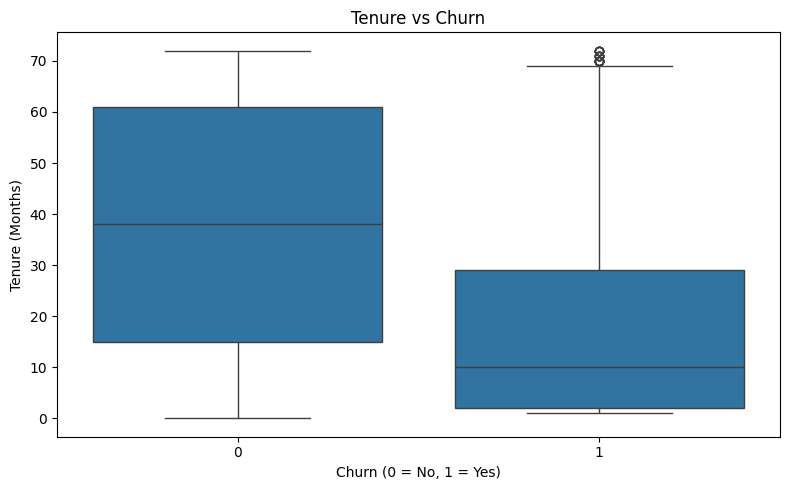

In [9]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure vs Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Tenure (Months)")

plt.tight_layout()
plt.show()

Monthly Charges vs Churn

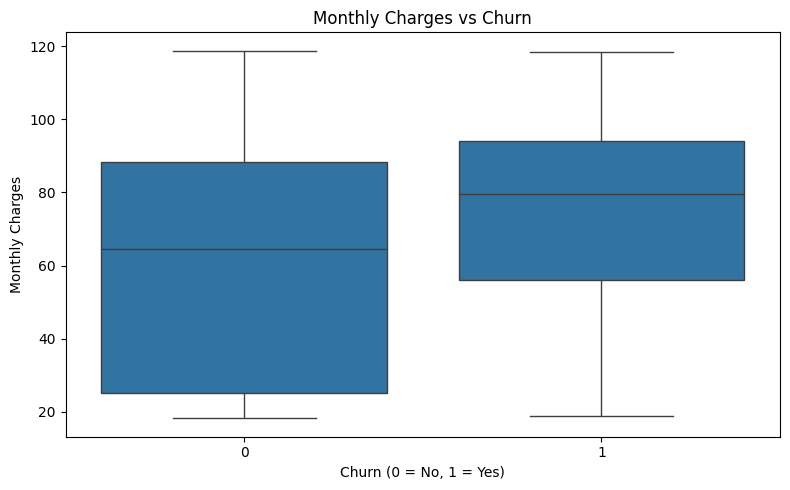

In [10]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

Total Charges vs Churn

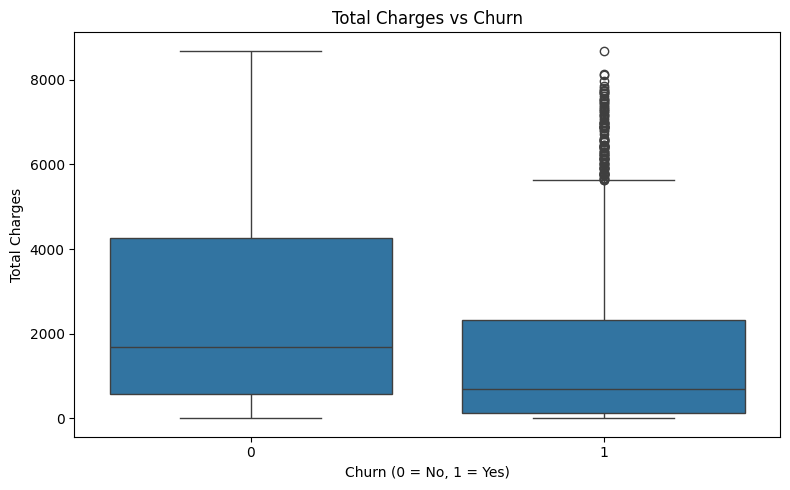

In [11]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges vs Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Total Charges")

plt.tight_layout()
plt.show()

tep 13 — Contract vs Churn

In [13]:
contract_columns = [
    "Contract_Month-to-month",
    "Contract_One year",
    "Contract_Two year"
]

contract_churn_results = {}

for col in contract_columns:
    if col in df.columns:
        contract_churn_results[col] = df.groupby(col)["Churn"].mean() * 100

contract_churn = pd.DataFrame(contract_churn_results)

print("Contract-wise churn analysis:")
print(contract_churn)

Contract-wise churn analysis:
   Contract_One year  Contract_Two year
0          30.574506          34.050112
1          11.269518           2.831858


In [14]:
contract_columns = [
    "Contract_Month-to-month",
    "Contract_One year",
    "Contract_Two year"
]

contract_churn = {}

for col in contract_columns:
    if col in df.columns:
        churn_rate = df.loc[df[col] == 1, "Churn"].mean() * 100
        contract_name = col.replace("Contract_", "")
        contract_churn[contract_name] = churn_rate

contract_churn = pd.Series(contract_churn).sort_values(ascending=False)

print("Contract-wise Churn Rate:")
print(contract_churn)

Contract-wise Churn Rate:
One year    11.269518
Two year     2.831858
dtype: float64


Contract Churn Graph

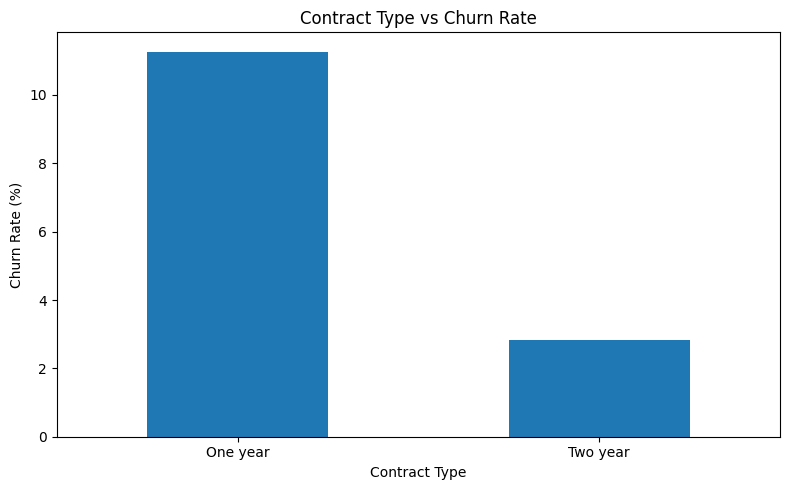

In [15]:
plt.figure(figsize=(8, 5))

contract_churn.plot(kind="bar")

plt.title("Contract Type vs Churn Rate")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [17]:
print(df.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [18]:
contract_columns = [
    col for col in df.columns
    if col.startswith("Contract_")
]

print("Contract columns found:")
print(contract_columns)

Contract columns found:
['Contract_One year', 'Contract_Two year']


In [19]:
contract_churn = {}

for col in contract_columns:
    churn_rate = df.loc[df[col] == 1, "Churn"].mean() * 100
    
    contract_name = col.replace("Contract_", "")
    contract_churn[contract_name] = churn_rate

contract_churn = pd.Series(contract_churn).sort_values(ascending=False)

print("Contract-wise Churn Rate:")
print(contract_churn)

Contract-wise Churn Rate:
One year    11.269518
Two year     2.831858
dtype: float64


Internet Service columns

In [20]:
internet_columns = [
    col for col in df.columns
    if col.startswith("InternetService_")
]

print("Internet Service columns found:")
print(internet_columns)

Internet Service columns found:
['InternetService_Fiber optic', 'InternetService_No']


Internet Service Churn Rate

In [21]:
internet_churn = {}

for col in internet_columns:
    churn_rate = df.loc[df[col] == 1, "Churn"].mean() * 100

    service_name = col.replace("InternetService_", "")
    internet_churn[service_name] = churn_rate

internet_churn = pd.Series(internet_churn).sort_values(ascending=False)

print("Internet Service-wise Churn Rate:")
print(internet_churn)

Internet Service-wise Churn Rate:
Fiber optic    41.892765
No              7.404980
dtype: float64


Graph

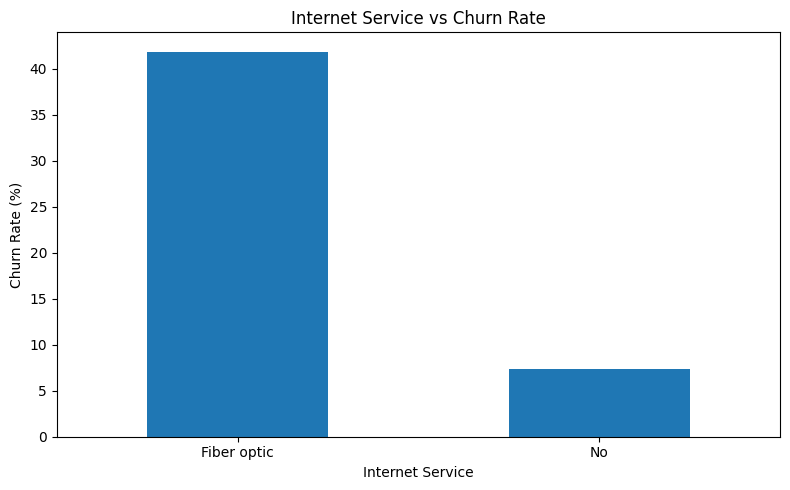

In [22]:
plt.figure(figsize=(8, 5))

internet_churn.plot(kind="bar")

plt.title("Internet Service vs Churn Rate")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [23]:
import os

os.makedirs("../Reports/week2", exist_ok=True)

print("Reports/week2 folder ready!")


Reports/week2 folder ready!


XGBoost package check

In [24]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


X, y

In [25]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Target values:")
print(y.value_counts())

Features shape: (7043, 30)
Target shape: (7043,)
Target values:
Churn
0    5174
1    1869
Name: count, dtype: int64


Train/Test split

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)
print("Training target  :", y_train.shape)
print("Testing target   :", y_test.shape)

Training features: (5634, 30)
Testing features : (1409, 30)
Training target  : (5634,)
Testing target   : (1409,)


XGBoost model create

In [27]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

print("XGBoost model created successfully!")

XGBoost model created successfully!


Train the model

In [28]:
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


Generate predictions

In [29]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 1409


Evaluation Metrics

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("XGBoost Model Performance")
print("=" * 35)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

XGBoost Model Performance
Accuracy : 0.7999
Precision: 0.6513
Recall   : 0.5294
F1 Score : 0.5841
ROC-AUC  : 0.8418


Classification Report

In [31]:
print("Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"]
    )
)

Classification Report
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.65      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



Confusion Matrix

Confusion Matrix:
[[929 106]
 [176 198]]


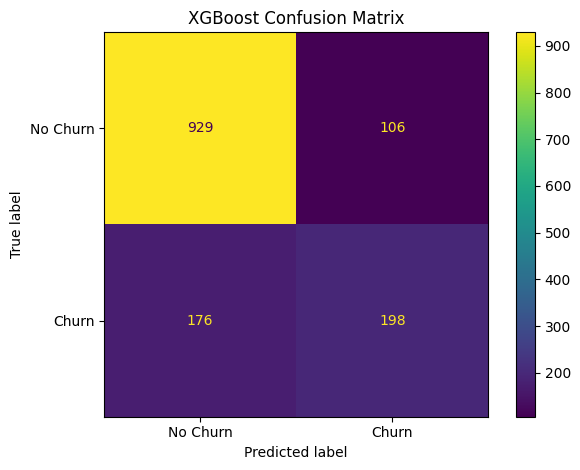

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

XGBoost Feature Importance

In [33]:
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 15 Important Features:")
print(feature_importance.head(15))

Top 15 Important Features:
InternetService_Fiber optic           0.224934
Contract_Two year                     0.179469
OnlineSecurity_No internet service    0.140716
Contract_One year                     0.077755
InternetService_No                    0.047304
OnlineBackup_No internet service      0.035418
PaymentMethod_Electronic check        0.035139
tenure                                0.026524
StreamingMovies_Yes                   0.022915
MultipleLines_No phone service        0.018507
PaperlessBilling_Yes                  0.018143
OnlineSecurity_Yes                    0.017315
TotalCharges                          0.016043
MultipleLines_Yes                     0.014225
TechSupport_Yes                       0.013721
dtype: float32


Feature Importance Graph

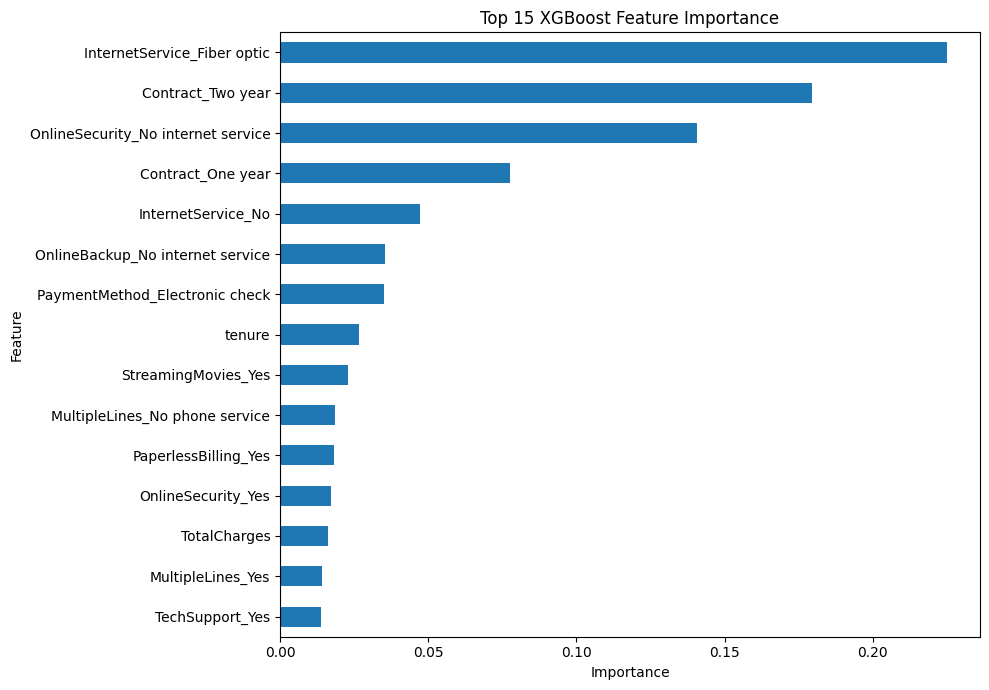

In [34]:
plt.figure(figsize=(10, 7))

feature_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

SHAP install/check

In [35]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


SHAP Explainer

In [36]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully!")
print("SHAP shape:", shap_values.shape)

SHAP values calculated successfully!
SHAP shape: (1409, 30)


SHAP Summary Plot

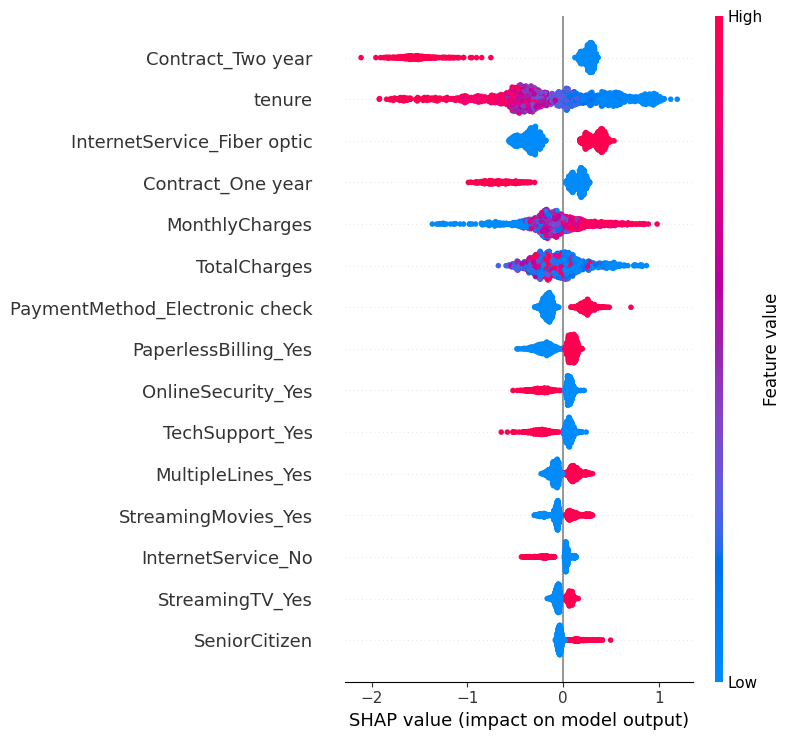

In [37]:
shap.summary_plot(
    shap_values,
    X_test,
    max_display=15
)

SHAP Bar Plot

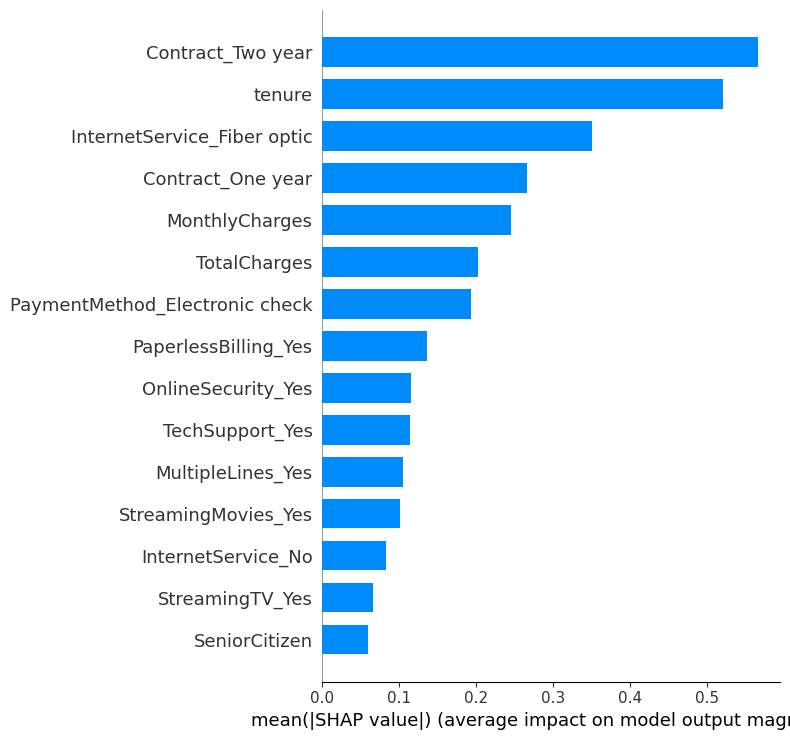

In [38]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    max_display=15
)

All libraries imported successfully!
Reports/week2 folder ready!
Dataset loaded successfully!
Dataset shape: (7043, 31)

First 5 rows:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


Column names:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Data types:
SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn    

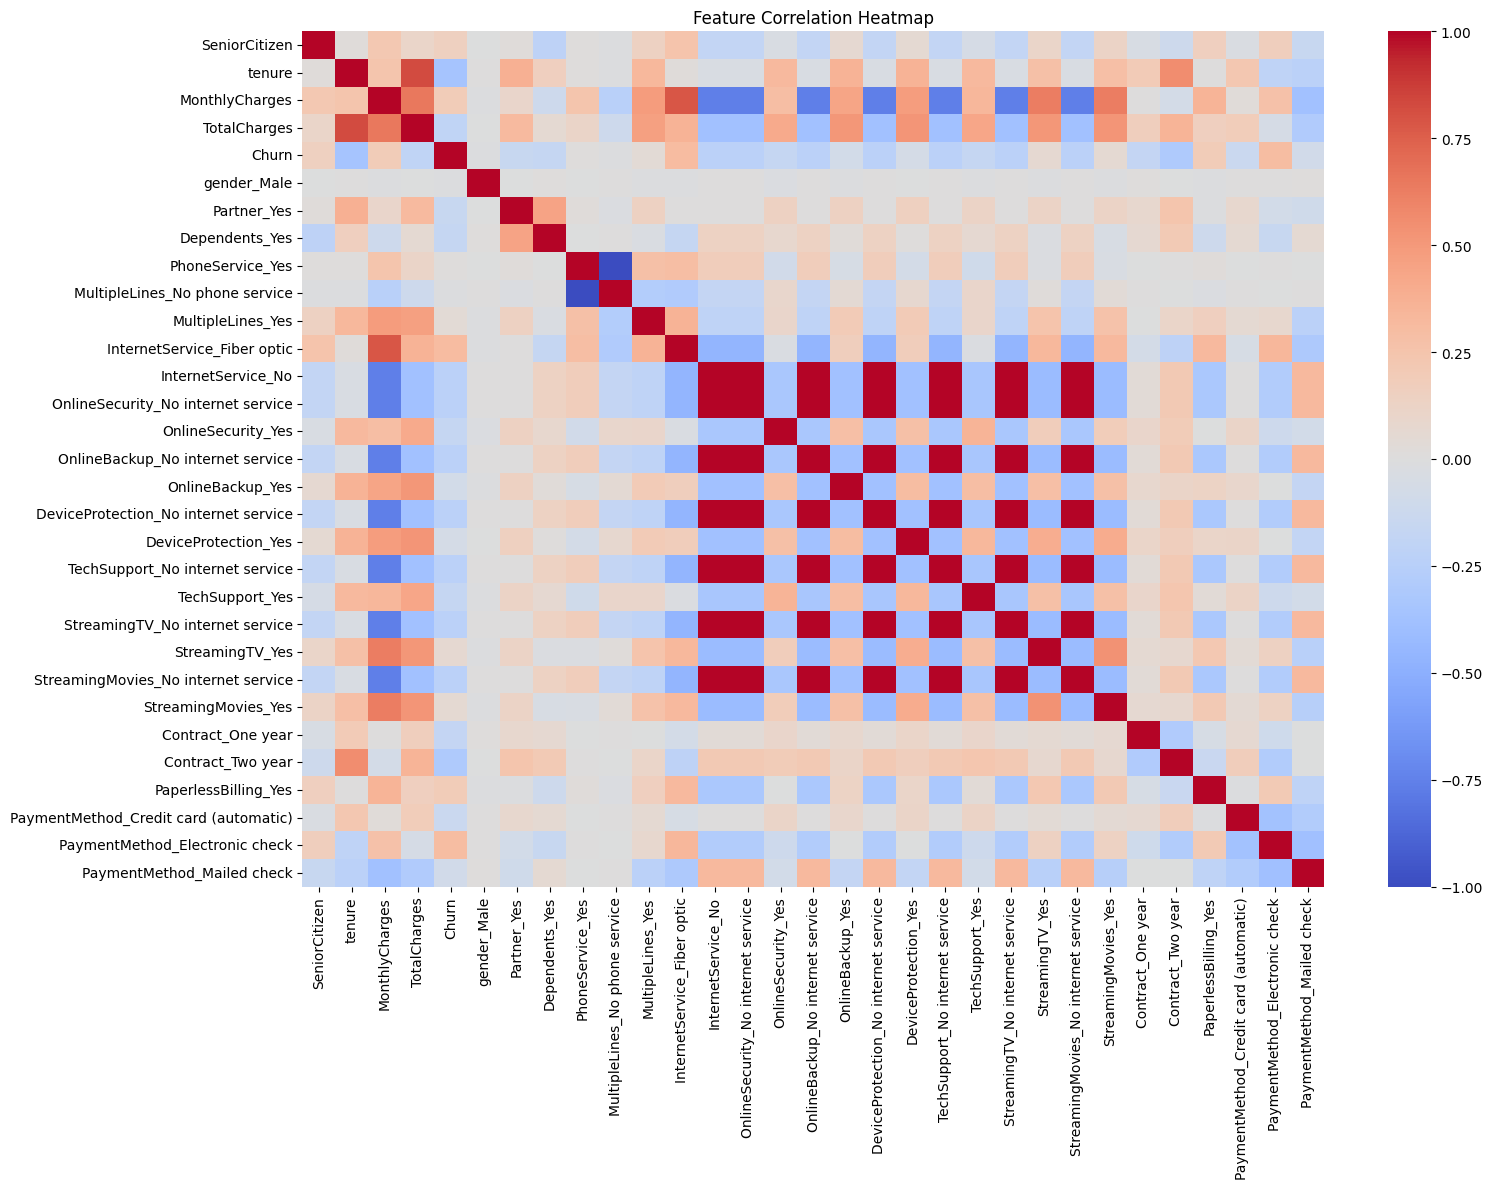

Correlation heatmap saved successfully!

TASK 2 - FEATURE VISUALIZATION & INSIGHTS
Contract columns found:
['Contract_One year', 'Contract_Two year']

Contract-wise Churn Rate:
One year    11.269518
Two year     2.831858
dtype: float64


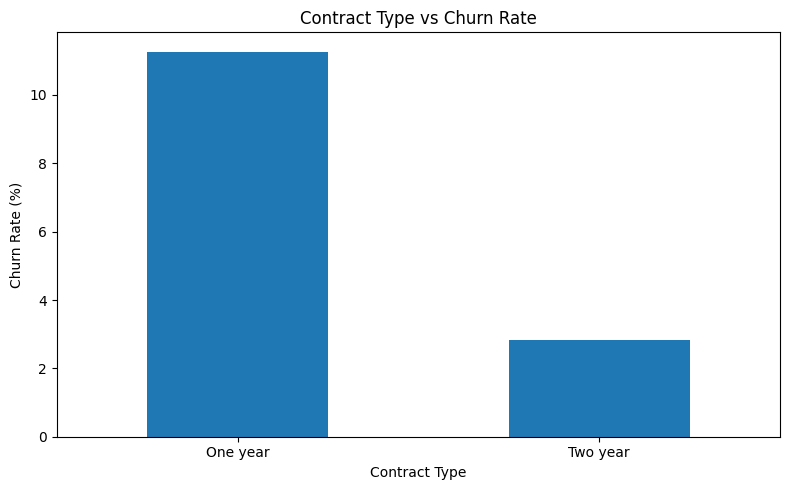

Contract chart saved successfully!

Internet Service columns found:
['InternetService_Fiber optic', 'InternetService_No']

Internet Service-wise Churn Rate:
Fiber optic    41.892765
No              7.404980
dtype: float64


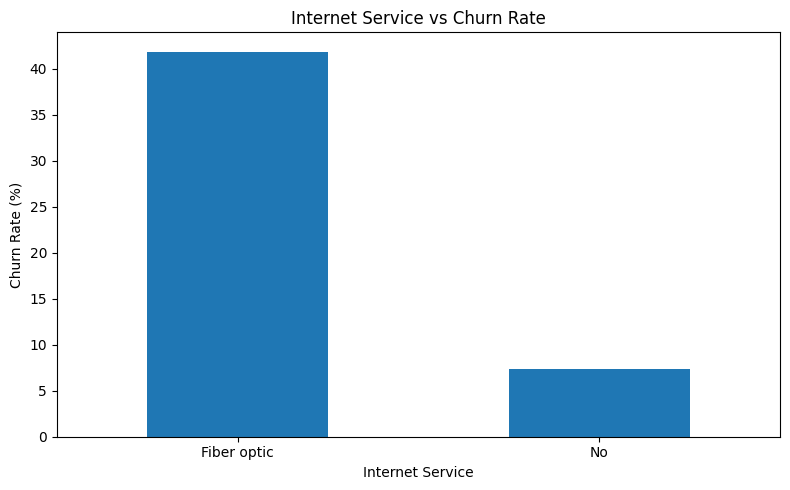

Internet Service chart saved successfully!


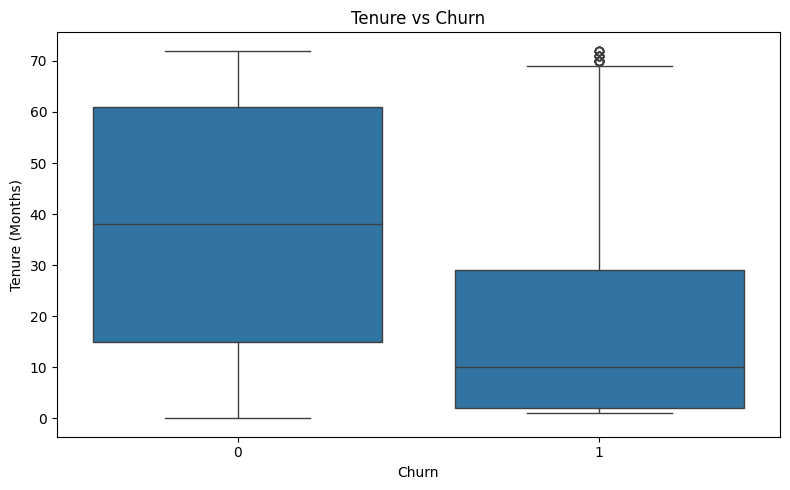

Tenure chart saved successfully!


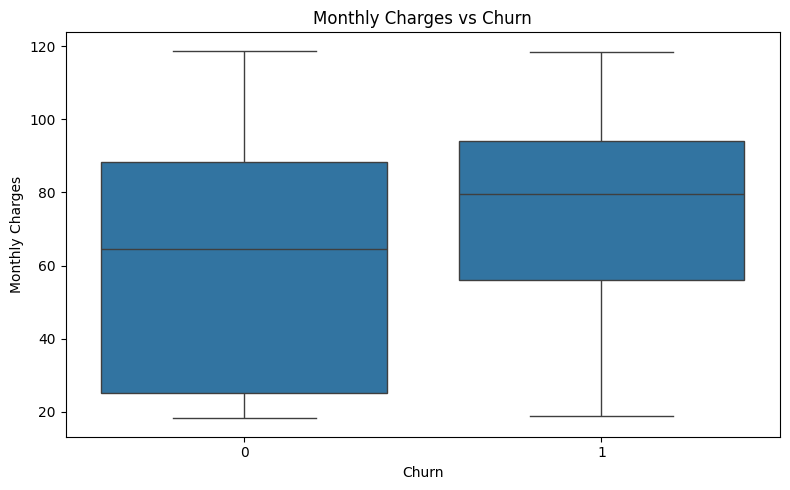

Monthly Charges chart saved successfully!


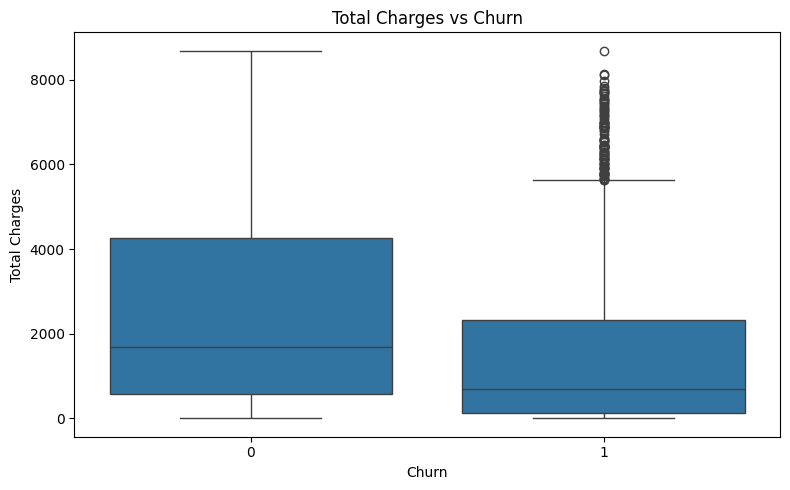

Total Charges chart saved successfully!

TASK 3 - XGBOOST MODEL TRAINING
Training features: (5634, 30)
Testing features : (1409, 30)
Training target  : (5634,)
Testing target   : (1409,)

XGBoost model created successfully!
XGBoost model trained successfully!
Predictions generated successfully!
Number of predictions: 1409

TASK 4 - XGBOOST EVALUATION

XGBoost Model Performance
Accuracy : 0.7999
Precision: 0.6513
Recall   : 0.5294
F1 Score : 0.5841
ROC-AUC  : 0.8418

Classification Report
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.65      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409


Confusion Matrix:
[[929 106]
 [176 198]]


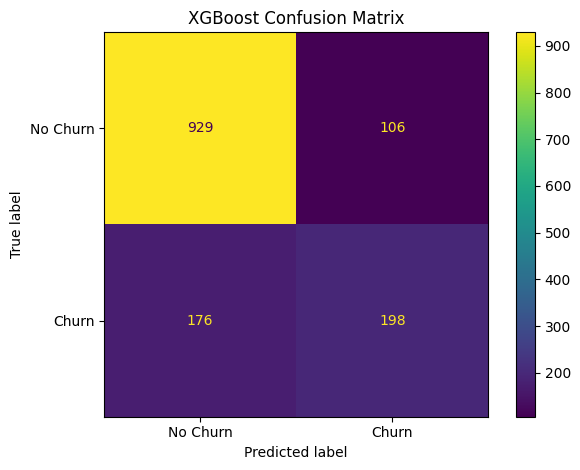

Confusion matrix saved successfully!

XGBOOST FEATURE IMPORTANCE

Top 15 Important Features:
InternetService_Fiber optic           0.224934
Contract_Two year                     0.179469
OnlineSecurity_No internet service    0.140716
Contract_One year                     0.077755
InternetService_No                    0.047304
OnlineBackup_No internet service      0.035418
PaymentMethod_Electronic check        0.035139
tenure                                0.026524
StreamingMovies_Yes                   0.022915
MultipleLines_No phone service        0.018507
PaperlessBilling_Yes                  0.018143
OnlineSecurity_Yes                    0.017315
TotalCharges                          0.016043
MultipleLines_Yes                     0.014225
TechSupport_Yes                       0.013721
dtype: float32


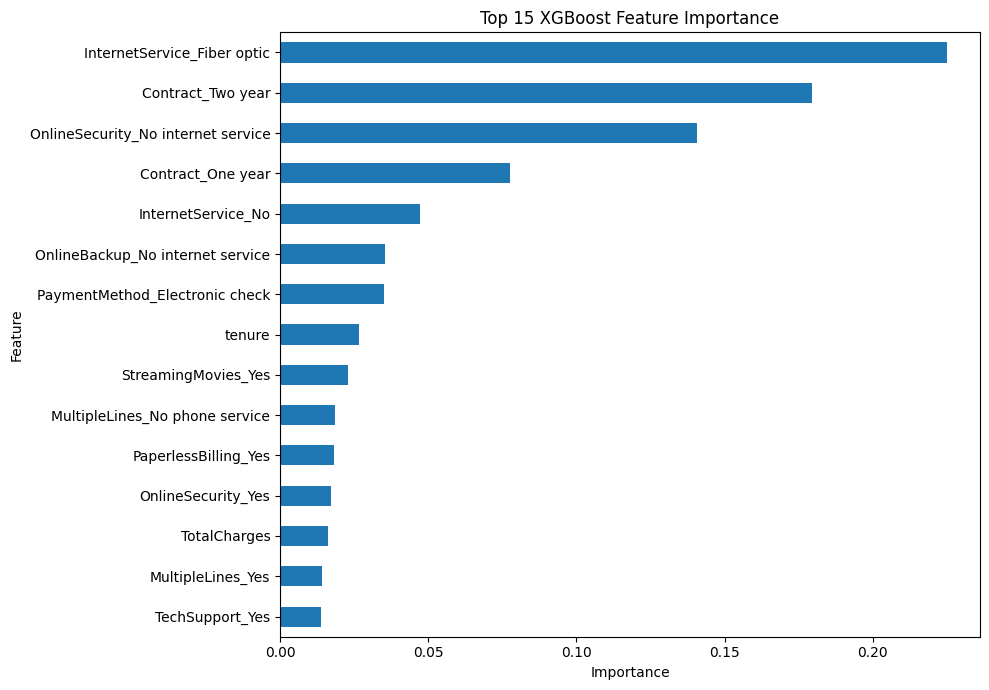

XGBoost feature importance chart saved successfully!

TASK 5 - SHAP EXPLAINABILITY
SHAP values calculated successfully!
SHAP shape: (1409, 30)


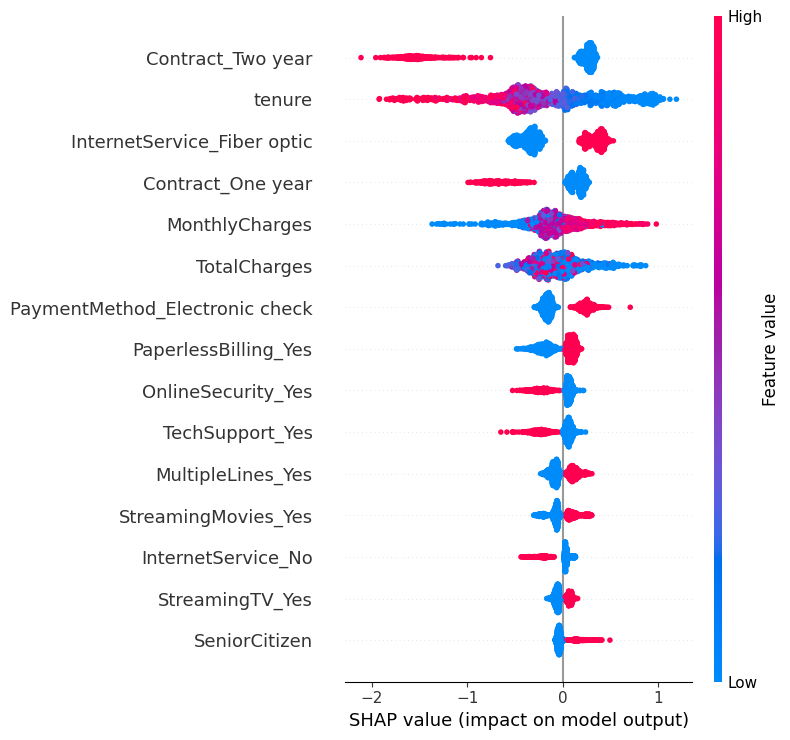

SHAP summary plot saved successfully!


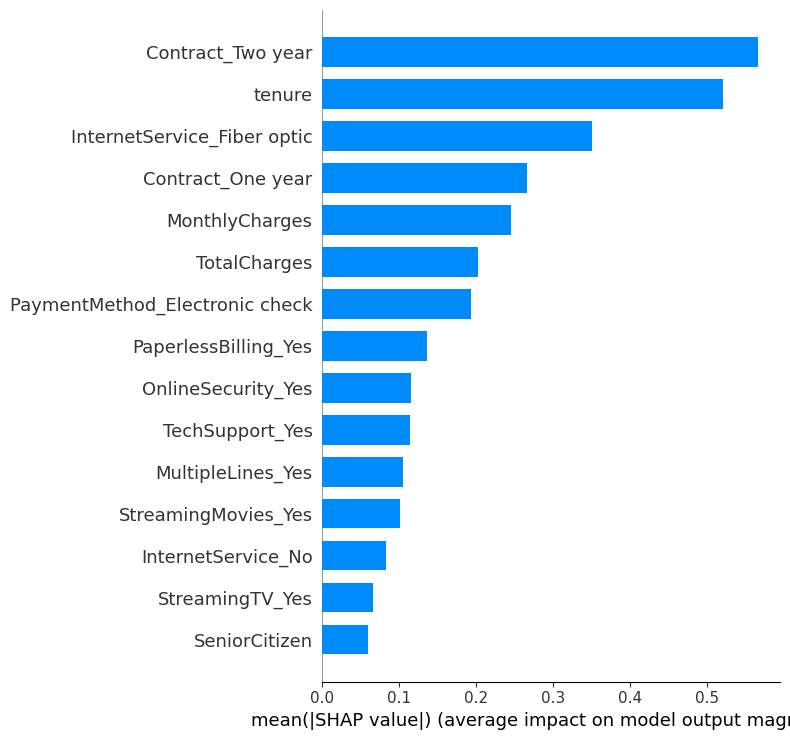

SHAP feature importance plot saved successfully!

Model results saved successfully!

PERSON 3 - WEEK 2 COMPLETED

1. Feature Correlation Analysis       - COMPLETED
2. Feature Visualization & Insights   - COMPLETED
3. XGBoost Model Training             - COMPLETED
4. XGBoost Evaluation                 - COMPLETED
5. Feature Importance                 - COMPLETED
6. SHAP Explainability                - COMPLETED

All charts and model results saved in ../Reports/week2/


In [39]:
# ============================================================
# PERSON 3 - WEEK 2
# Feature Correlation + Visualization
# XGBoost + Evaluation + SHAP
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import xgboost as xgb
import shap

warnings.filterwarnings("ignore")

print("All libraries imported successfully!")


# ------------------------------------------------------------
# 2. CREATE REPORTS FOLDER
# ------------------------------------------------------------

os.makedirs("../Reports/week2", exist_ok=True)

print("Reports/week2 folder ready!")


# ------------------------------------------------------------
# 3. LOAD ENCODED DATASET
# ------------------------------------------------------------

DATA_PATH = "../data/processed/telco_person3_week1_cleaned_encoded.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())


# ------------------------------------------------------------
# 4. CHECK DATA
# ------------------------------------------------------------

print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())


# ------------------------------------------------------------
# 5. SEPARATE FEATURES AND TARGET
# ------------------------------------------------------------

X = df.drop(columns=["Churn"])
y = df["Churn"]

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())


# ============================================================
# TASK 1 - FEATURE CORRELATION ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("TASK 1 - FEATURE CORRELATION ANALYSIS")
print("=" * 60)


# Calculate correlations

correlation_matrix = df.corr(numeric_only=True)

print("Correlation matrix created successfully!")

print("\nTop correlations with Churn:")

churn_correlation = (
    correlation_matrix["Churn"]
    .sort_values(ascending=False)
)

print(churn_correlation)


# ------------------------------------------------------------
# 6. CORRELATION HEATMAP
# ------------------------------------------------------------

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "../Reports/week2/person3_feature_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Correlation heatmap saved successfully!")


# ============================================================
# TASK 2 - FEATURE VISUALIZATION & INSIGHTS
# ============================================================

print("\n" + "=" * 60)
print("TASK 2 - FEATURE VISUALIZATION & INSIGHTS")
print("=" * 60)


# ------------------------------------------------------------
# 7. CONTRACT VS CHURN
# ------------------------------------------------------------

contract_columns = [
    col for col in df.columns
    if col.startswith("Contract_")
]

print("Contract columns found:")
print(contract_columns)


contract_churn = {}

for col in contract_columns:

    churn_rate = (
        df.loc[df[col] == 1, "Churn"].mean() * 100
    )

    contract_name = col.replace("Contract_", "")

    contract_churn[contract_name] = churn_rate


contract_churn = (
    pd.Series(contract_churn)
    .sort_values(ascending=False)
)

print("\nContract-wise Churn Rate:")
print(contract_churn)


# Contract graph

plt.figure(figsize=(8, 5))

contract_churn.plot(kind="bar")

plt.title("Contract Type vs Churn Rate")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../Reports/week2/person3_contract_vs_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Contract chart saved successfully!")


# ------------------------------------------------------------
# 8. INTERNET SERVICE VS CHURN
# ------------------------------------------------------------

internet_columns = [
    col for col in df.columns
    if col.startswith("InternetService_")
]

print("\nInternet Service columns found:")
print(internet_columns)


internet_churn = {}

for col in internet_columns:

    churn_rate = (
        df.loc[df[col] == 1, "Churn"].mean() * 100
    )

    service_name = col.replace("InternetService_", "")

    internet_churn[service_name] = churn_rate


internet_churn = (
    pd.Series(internet_churn)
    .sort_values(ascending=False)
)

print("\nInternet Service-wise Churn Rate:")
print(internet_churn)


# Internet Service graph

plt.figure(figsize=(8, 5))

internet_churn.plot(kind="bar")

plt.title("Internet Service vs Churn Rate")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../Reports/week2/person3_internet_service_vs_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Internet Service chart saved successfully!")


# ------------------------------------------------------------
# 9. TENURE VS CHURN
# ------------------------------------------------------------

if "tenure" in df.columns:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        x="Churn",
        y="tenure",
        data=df
    )

    plt.title("Tenure vs Churn")
    plt.xlabel("Churn")
    plt.ylabel("Tenure (Months)")

    plt.tight_layout()

    plt.savefig(
        "../Reports/week2/person3_tenure_vs_churn.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Tenure chart saved successfully!")


# ------------------------------------------------------------
# 10. MONTHLY CHARGES VS CHURN
# ------------------------------------------------------------

if "MonthlyCharges" in df.columns:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        x="Churn",
        y="MonthlyCharges",
        data=df
    )

    plt.title("Monthly Charges vs Churn")
    plt.xlabel("Churn")
    plt.ylabel("Monthly Charges")

    plt.tight_layout()

    plt.savefig(
        "../Reports/week2/person3_monthly_charges_vs_churn.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Monthly Charges chart saved successfully!")


# ------------------------------------------------------------
# 11. TOTAL CHARGES VS CHURN
# ------------------------------------------------------------

if "TotalCharges" in df.columns:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        x="Churn",
        y="TotalCharges",
        data=df
    )

    plt.title("Total Charges vs Churn")
    plt.xlabel("Churn")
    plt.ylabel("Total Charges")

    plt.tight_layout()

    plt.savefig(
        "../Reports/week2/person3_total_charges_vs_churn.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Total Charges chart saved successfully!")


# ============================================================
# TASK 3 - XGBOOST MODEL TRAINING
# ============================================================

print("\n" + "=" * 60)
print("TASK 3 - XGBOOST MODEL TRAINING")
print("=" * 60)


# ------------------------------------------------------------
# 12. TRAIN TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)
print("Training target  :", y_train.shape)
print("Testing target   :", y_test.shape)


# ------------------------------------------------------------
# 13. CREATE XGBOOST MODEL
# ------------------------------------------------------------

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

print("\nXGBoost model created successfully!")


# ------------------------------------------------------------
# 14. TRAIN MODEL
# ------------------------------------------------------------

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost model trained successfully!")


# ------------------------------------------------------------
# 15. PREDICTIONS
# ------------------------------------------------------------

y_pred = xgb_model.predict(X_test)

y_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))


# ============================================================
# TASK 4 - XGBOOST EVALUATION
# ============================================================

print("\n" + "=" * 60)
print("TASK 4 - XGBOOST EVALUATION")
print("=" * 60)


# ------------------------------------------------------------
# 16. EVALUATION METRICS
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


print("\nXGBoost Model Performance")
print("=" * 35)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")


# ------------------------------------------------------------
# 17. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\nClassification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)


# ------------------------------------------------------------
# 18. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No Churn",
        "Churn"
    ]
)

disp.plot()

plt.title("XGBoost Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../Reports/week2/person3_xgboost_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved successfully!")


# ============================================================
# FEATURE IMPORTANCE
# ============================================================

print("\n" + "=" * 60)
print("XGBOOST FEATURE IMPORTANCE")
print("=" * 60)


# ------------------------------------------------------------
# 19. FEATURE IMPORTANCE
# ------------------------------------------------------------

feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(
    ascending=False
)


print("\nTop 15 Important Features:")

print(
    feature_importance.head(15)
)


# ------------------------------------------------------------
# 20. FEATURE IMPORTANCE GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

feature_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 15 XGBoost Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../Reports/week2/person3_xgboost_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("XGBoost feature importance chart saved successfully!")


# ============================================================
# TASK 5 - SHAP EXPLAINABILITY
# ============================================================

print("\n" + "=" * 60)
print("TASK 5 - SHAP EXPLAINABILITY")
print("=" * 60)


# ------------------------------------------------------------
# 21. SHAP EXPLAINER
# ------------------------------------------------------------

explainer = shap.TreeExplainer(
    xgb_model
)

shap_values = explainer.shap_values(
    X_test
)

print("SHAP values calculated successfully!")
print("SHAP shape:", shap_values.shape)


# ------------------------------------------------------------
# 22. SHAP SUMMARY PLOT
# ------------------------------------------------------------

shap.summary_plot(
    shap_values,
    X_test,
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../Reports/week2/person3_shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SHAP summary plot saved successfully!")


# ------------------------------------------------------------
# 23. SHAP BAR PLOT
# ------------------------------------------------------------

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../Reports/week2/person3_shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SHAP feature importance plot saved successfully!")


# ============================================================
# 24. SAVE MODEL PERFORMANCE RESULTS
# ============================================================

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results.to_csv(
    "../Reports/week2/person3_xgboost_model_results.csv",
    index=False
)

print("\nModel results saved successfully!")


# ============================================================
# 25. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("PERSON 3 - WEEK 2 COMPLETED")
print("=" * 60)

print("""
1. Feature Correlation Analysis       - COMPLETED
2. Feature Visualization & Insights   - COMPLETED
3. XGBoost Model Training             - COMPLETED
4. XGBoost Evaluation                 - COMPLETED
5. Feature Importance                 - COMPLETED
6. SHAP Explainability                - COMPLETED
""")

print("All charts and model results saved in ../Reports/week2/")